<a href="https://colab.research.google.com/github/Kevin-2003/WasteDetection/blob/main/resnet_trashnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cd /content/drive/MyDrive/trashnet_new/train

/content/drive/.shortcut-targets-by-id/1R2HyLP-e-NUJ45gVeht1ETepdqKM9CIk/trashnet_new/train


In [ ]:
os.environ["data_dir"] = "/content/drive/MyDrive/trashnet_new/train"

In [ ]:
import pathlib

In [ ]:
data_dir = pathlib.Path("/content/drive/MyDrive/trashnet_new/train")
print(data_dir)

/content/drive/MyDrive/trashnet_new/train


/content/drive/MyDrive/trashnet_new/train/glass/glass230.jpg


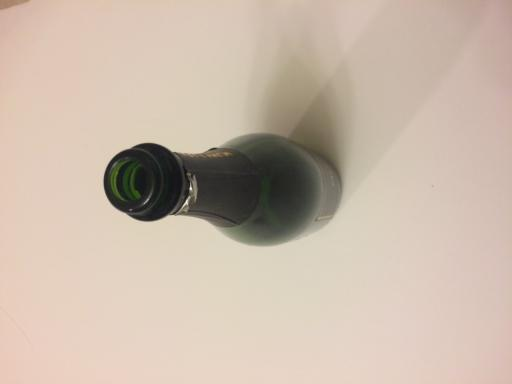

In [ ]:
glass = list(data_dir.glob('glass/*'))
print(glass[1])
PIL.Image.open(str(glass[1]))

In [ ]:
img_height,img_width=512,512

In [ ]:

batch_size=32
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  # validation_split=0.2,
  # subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 1671 files belonging to 5 classes.


In [ ]:
val_dir = pathlib.Path("/content/drive/MyDrive/trashnet_new/val")
print(val_dir)

/content/drive/MyDrive/trashnet_new/val


In [ ]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  val_dir,
  # validation_split=0.2,
  # subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 476 files belonging to 5 classes.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic']


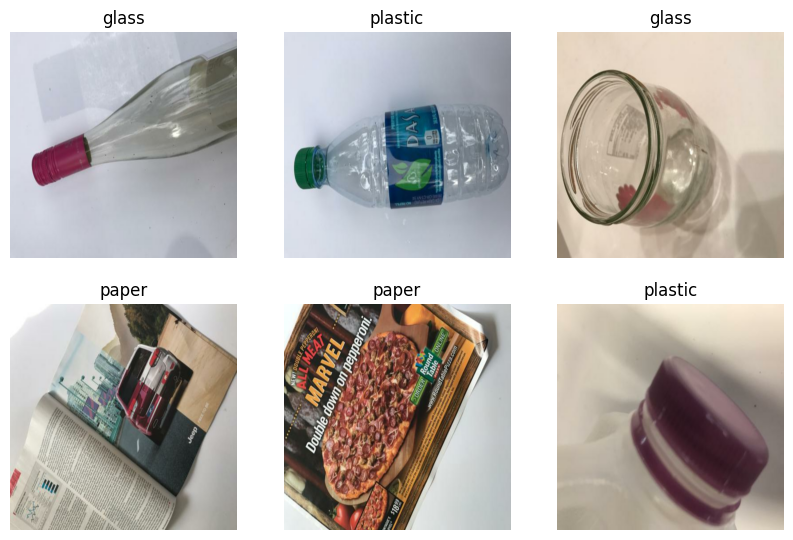

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(6):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
def preprocess(image, label):
  """Preprocesses the image and label."""
  image = tf.image.resize(image, [512,512])
  # One-hot encode the labels
  label = tf.one_hot(label, depth=5)
  return image, label

# Apply the preprocessing function to your datasets
train_ds = train_ds.map(preprocess)
val_ds = val_ds.map(preprocess)

In [ ]:
resnet_model = Sequential()

pretrained_model= tf.keras.applications.ResNet50(include_top=False,
                   input_shape=(512,512,3),
                   pooling='avg',classes=5,
                   weights='imagenet')
for layer in pretrained_model.layers:
        layer.trainable=False

resnet_model.add(Input(shape=(512,512, 3)))
resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(512, activation='relu'))
resnet_model.add(Dense(5, activation='softmax'))

In [ ]:
resnet_model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 flatten_1 (Flatten)         (None, 2048)              0         
                                                                 
 dense_2 (Dense)             (None, 512)               1049088   
                                                                 
 dense_3 (Dense)             (None, 5)                 2565      
                                                                 
Total params: 24639365 (93.99 MB)
Trainable params: 1051653 (4.01 MB)
Non-trainable params: 23587712 (89.98 MB)
_________________________________________________________________


In [ ]:
resnet_model.compile(optimizer=Adam(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])
# Changed 'lr' to 'learning_rate' in the Adam optimizer initialization

In [ ]:
epochs=20
history = resnet_model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20
53/53 [==============================] - 198s 4s/step - loss: 0.6570 - accuracy: 0.7618 - val_loss: 0.3781 - val_accuracy: 0.8697
Epoch 2/20
53/53 [==============================] - 198s 4s/step - loss: 0.2329 - accuracy: 0.9102 - val_loss: 0.3403 - val_accuracy: 0.8803
Epoch 3/20
53/53 [==============================] - 197s 4s/step - loss: 0.1707 - accuracy: 0.9396 - val_loss: 0.3509 - val_accuracy: 0.8824
Epoch 4/20
53/53 [==============================] - 197s 4s/step - loss: 0.1068 - accuracy: 0.9653 - val_loss: 0.2943 - val_accuracy: 0.9055
Epoch 5/20
53/53 [==============================] - 199s 4s/step - loss: 0.0650 - accuracy: 0.9880 - val_loss: 0.3175 - val_accuracy: 0.9055
Epoch 6/20
53/53 [==============================] - 199s 4s/step - loss: 0.0433 - accuracy: 0.9940 - val_loss: 0.3374 - val_accuracy: 0.8950
Epoch 7/20
53/53 [==============================] - 200s 4s/step - loss: 0.0436 - accuracy: 0.9928 - val_loss: 0.3644 - val_accuracy: 0.8908
Epoch 8/20
53

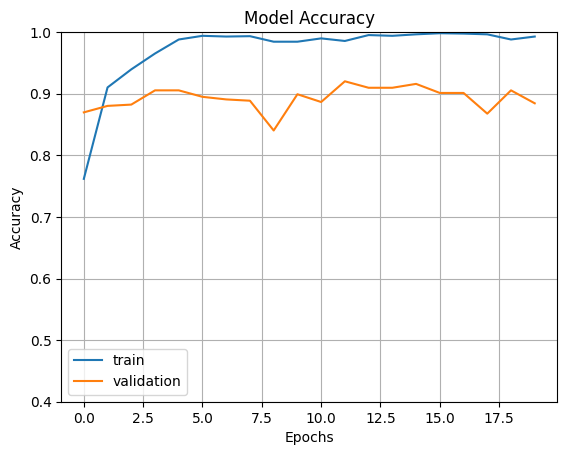

In [ ]:
fig1 = plt.gcf()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.axis(ymin=0.4,ymax=1)
plt.grid()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

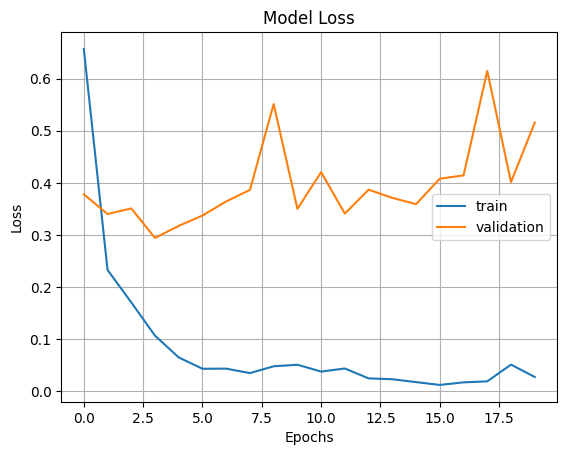

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.grid()
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

In [ ]:
test_dir = "/content/drive/MyDrive/trashnet_new/test"
val_dir = "/content/drive/MyDrive/trashnet_new/val"

In [ ]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,  # Replace with the path to your validation directory
    image_size=(img_height, img_width),
    batch_size=batch_size
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,  # Replace with the path to your testing directory
    image_size=(img_height, img_width),
    batch_size=batch_size
)


Found 476 files belonging to 5 classes.
Found 243 files belonging to 5 classes.


In [ ]:
val_ds = val_ds.map(preprocess)  # if you have a preprocessing function called preprocess
test_ds = test_ds.map(preprocess)


In [ ]:
# Evaluate on the validation set
val_loss, val_accuracy = resnet_model.evaluate(val_ds)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")

# Evaluate on the testing set
test_loss, test_accuracy = resnet_model.evaluate(test_ds)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

15/15 [==============================] - 45s 3s/step - loss: 0.5156 - accuracy: 0.8845
Validation Loss: 0.5156281590461731
Validation Accuracy: 0.8844537734985352
8/8 [==============================] - 23s 3s/step - loss: 0.5919 - accuracy: 0.8724
Test Loss: 0.5919491052627563
Test Accuracy: 0.8724279999732971


In [ ]:
import cv2
os.environ["testing_dir"] = "/content/drive/MyDrive/Testingimages "
testing_dir = pathlib.Path("/content/drive/MyDrive/Testingimages ")

plastic = list(testing_dir.glob('*'))
# print(plastic)
# print(plastic[4])
PIL.Image.open(str("/content/drive/MyDrive/Testingimages /IMG_2024-11-09-182600.jpg"))

image=cv2.imread(str("/content/drive/MyDrive/Testingimages /IMG_2024-11-09-182600.jpg"))
image_resized= cv2.resize(image, (img_width,img_height))
image=np.expand_dims(image_resized,axis=0)
print(image.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Testingimages /IMG_2024-11-09-182600.jpg'

In [ ]:
pred=resnet_model.predict(image)
print(pred)

1/1 [==============================] - 1s 968ms/step
[[9.9864858e-01 6.7602542e-11 2.3992566e-10 1.3510309e-03 3.3596703e-07]]


In [ ]:
output_class=class_names[np.argmax(pred)]
print("The predicted class is", output_class)

The predicted class is cardboard


In [ ]:
PIL.Image.open(str("/content/drive/MyDrive/Testingimages /IMG_2024-11-09-182840.jpg"))

image=cv2.imread(str("/content/drive/MyDrive/Testingimages /IMG_2024-11-09-182840.jpg"))
image_resized= cv2.resize(image, (img_width,img_height))
image=np.expand_dims(image_resized,axis=0)
print(image.shape)



(1, 384, 384, 3)


In [ ]:
pred=resnet_model.predict(image)
print(pred)

1/1 [==============================] - 0s 124ms/step
[[2.5111156e-02 3.4243319e-14 4.3150367e-10 9.7481596e-01 7.2861687e-05]]


In [ ]:
output_class=class_names[np.argmax(pred)]
print("The predicted class is", output_class)

The predicted class is paper


In [ ]:
PIL.Image.open(str("/content/drive/MyDrive/Testingimages /IMG_2024-11-09-183618.jpg"))

image=cv2.imread(str("/content/drive/MyDrive/Testingimages /IMG_2024-11-09-183618.jpg"))
image_resized= cv2.resize(image, (img_width,img_height))
image=np.expand_dims(image_resized,axis=0)
print(image.shape)



(1, 384, 384, 3)


In [ ]:
pred=resnet_model.predict(image)
print(pred)

1/1 [==============================] - 0s 117ms/step
[[7.8548946e-06 6.9534261e-04 9.0816524e-04 3.1122316e-02 9.6726626e-01]]


In [ ]:
output_class=class_names[np.argmax(pred)]
print("The predicted class is", output_class)

The predicted class is plastic


In [ ]:
resnet_model.save("trash_model_512.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
model_json = resnet_model.to_json()
with open("resnet_model_architecture.json", "w") as json_file:
    json_file.write(model_json)

In [ ]:
PIL.Image.open(str("/content/drive/MyDrive/Testingimages /IMG_2024-11-09-185322.jpg"))

image=cv2.imread(str("/content/drive/MyDrive/Testingimages /IMG_2024-11-09-185322.jpg"))
image_resized= cv2.resize(image, (img_width,img_height))
image=np.expand_dims(image_resized,axis=0)
print(image.shape)



(1, 384, 384, 3)


In [ ]:
pred=resnet_model.predict(image)
print(pred)

1/1 [==============================] - 0s 114ms/step
[[9.9999225e-01 3.1635016e-12 2.5051065e-07 7.3827355e-06 1.0817262e-07]]


In [ ]:
output_class=class_names[np.argmax(pred)]
print("The predicted class is", output_class)

The predicted class is cardboard


In [ ]:
model = tf.keras.models.load_model('trash_model_512.h5')

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

In [ ]:
with open('trash_model_512.tflite', 'wb') as f:
    f.write(tflite_model)